In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('vader_lexicon', quiet=True)

True

In [3]:
# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("🏦 Ethiopian Banking Apps - Customer Experience Analytics")
print("="*60)

🏦 Ethiopian Banking Apps - Customer Experience Analytics


#### DATA LOADING AND BASIC EXPLORATION

In [5]:

# Load the cleaned data
df = pd.read_csv('../data/cleaned_reviews.csv')

print(f"📊 Dataset Overview:")
print(f"Total Reviews: {len(df):,}")
print(f"Date Range: {df['date'].min()} to {df['date'].max()}")
print(f"Banks Analyzed: {', '.join(df['bank'].unique())}")
print(f"Data Quality: {((df.notna().sum().sum() / (len(df) * len(df.columns))) * 100):.1f}% complete")

# Display basic statistics
print("\n📈 Reviews per Bank:")
bank_counts = df['bank'].value_counts()
for bank, count in bank_counts.items():
    print(f"  {bank}: {count:,} reviews")

print("\n⭐ Rating Distribution:")
rating_dist = df['rating'].value_counts().sort_index()
for rating, count in rating_dist.items():
    print(f"  {rating} stars: {count:,} reviews ({count/len(df)*100:.1f}%)")

📊 Dataset Overview:
Total Reviews: 1,031
Date Range: 2024-07-16 to 2025-06-07
Banks Analyzed: CBE, BOA, Dashen
Data Quality: 97.3% complete

📈 Reviews per Bank:
  Dashen: 366 reviews
  BOA: 344 reviews
  CBE: 321 reviews

⭐ Rating Distribution:
  1 stars: 241 reviews (23.4%)
  2 stars: 42 reviews (4.1%)
  3 stars: 56 reviews (5.4%)
  4 stars: 72 reviews (7.0%)
  5 stars: 620 reviews (60.1%)


SENTIMENT ANALYSIS IMPLEMENTATION

In [6]:

print("\n🎯 Performing Sentiment Analysis...")

# Initialize VADER analyzer
analyzer = SentimentIntensityAnalyzer()

def get_textblob_sentiment(text):
    """Get sentiment using TextBlob"""
    try:
        analysis = TextBlob(str(text))
        polarity = analysis.sentiment.polarity
        if polarity > 0.1:
            return 'positive'
        elif polarity < -0.1:
            return 'negative'
        else:
            return 'neutral'
    except:
        return 'neutral'

def get_vader_sentiment(text):
    """Get sentiment using VADER"""
    try:
        scores = analyzer.polarity_scores(str(text))
        compound = scores['compound']
        if compound >= 0.05:
            return 'positive'
        elif compound <= -0.05:
            return 'negative'
        else:
            return 'neutral'
    except:
        return 'neutral'

def get_rating_based_sentiment(rating):
    """Convert rating to sentiment"""
    if rating >= 4:
        return 'positive'
    elif rating <= 2:
        return 'negative'
    else:
        return 'neutral'

# Apply sentiment analysis
print("  Applying TextBlob sentiment analysis...")
df['sentiment_textblob'] = df['review'].apply(get_textblob_sentiment)

print("  Applying VADER sentiment analysis...")
df['sentiment_vader'] = df['review'].apply(get_vader_sentiment)

print("  Creating rating-based sentiment...")
df['sentiment_rating'] = df['rating'].apply(get_rating_based_sentiment)


🎯 Performing Sentiment Analysis...
  Applying TextBlob sentiment analysis...
  Applying VADER sentiment analysis...
  Creating rating-based sentiment...


SENTIMENT ANALYSIS RESULTS


📊 Sentiment Analysis Results:


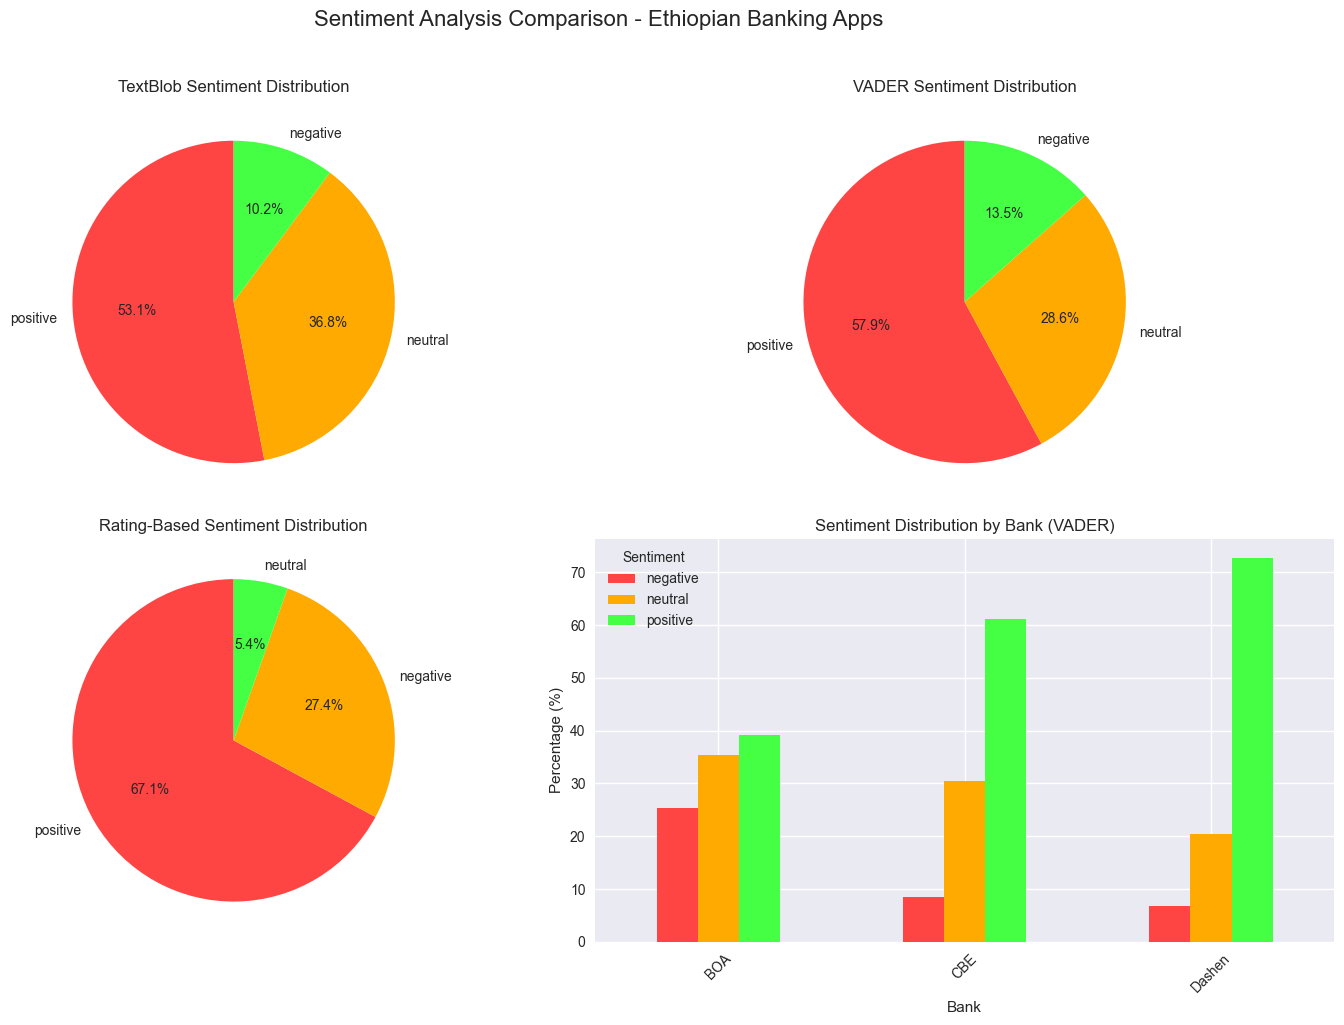


📈 Detailed Sentiment Statistics (VADER):

CBE:
  Positive: 196 (61.1%)
  Neutral:  98 (30.5%)
  Negative: 27 (8.4%)

BOA:
  Positive: 135 (39.2%)
  Neutral:  122 (35.5%)
  Negative: 87 (25.3%)

Dashen:
  Positive: 266 (72.7%)
  Neutral:  75 (20.5%)
  Negative: 25 (6.8%)


In [7]:

print("\n📊 Sentiment Analysis Results:")

# Compare different sentiment methods
methods = ['sentiment_textblob', 'sentiment_vader', 'sentiment_rating']
method_names = ['TextBlob', 'VADER', 'Rating-Based']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Sentiment Analysis Comparison - Ethiopian Banking Apps', fontsize=16, y=1.02)

# Overall sentiment distribution
for i, (method, name) in enumerate(zip(methods, method_names)):
    ax = axes[0, i] if i < 2 else axes[1, 0]
    sentiment_counts = df[method].value_counts()
    colors = ['#ff4444', '#ffaa00', '#44ff44']  # red, orange, green
    
    ax.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', 
           colors=colors, startangle=90)
    ax.set_title(f'{name} Sentiment Distribution')

# Sentiment by bank (using VADER as primary)
ax = axes[1, 1]
sentiment_bank = pd.crosstab(df['bank'], df['sentiment_vader'], normalize='index') * 100
sentiment_bank.plot(kind='bar', ax=ax, color=['#ff4444', '#ffaa00', '#44ff44'])
ax.set_title('Sentiment Distribution by Bank (VADER)')
ax.set_xlabel('Bank')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Sentiment')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('sentiment_analysis_overview.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed sentiment statistics
print("\n📈 Detailed Sentiment Statistics (VADER):")
for bank in df['bank'].unique():
    bank_data = df[df['bank'] == bank]
    sentiment_counts = bank_data['sentiment_vader'].value_counts()
    total = len(bank_data)
    
    print(f"\n{bank}:")
    print(f"  Positive: {sentiment_counts.get('positive', 0):,} ({sentiment_counts.get('positive', 0)/total*100:.1f}%)")
    print(f"  Neutral:  {sentiment_counts.get('neutral', 0):,} ({sentiment_counts.get('neutral', 0)/total*100:.1f}%)")
    print(f"  Negative: {sentiment_counts.get('negative', 0):,} ({sentiment_counts.get('negative', 0)/total*100:.1f}%)")

KEYWORD EXTRACTION AND THEME ANALYSIS

In [8]:

print("\n🔍 Performing Keyword Extraction and Theme Analysis...")

# Prepare text for analysis
stop_words = set(stopwords.words('english'))
additional_stops = {'app', 'bank', 'banking', 'mobile', 'cbe', 'boa', 'dashen', 'one', 'use', 'get', 'go', 'time'}
stop_words.update(additional_stops)

def extract_keywords_tfidf(texts, max_features=20):
    """Extract keywords using TF-IDF"""
    vectorizer = TfidfVectorizer(
        max_features=max_features,
        stop_words=list(stop_words),
        ngram_range=(1, 2),
        min_df=2
    )
    
    try:
        tfidf_matrix = vectorizer.fit_transform(texts.fillna(''))
        feature_names = vectorizer.get_feature_names_out()
        scores = tfidf_matrix.sum(axis=0).A1
        
        keyword_scores = list(zip(feature_names, scores))
        keyword_scores.sort(key=lambda x: x[1], reverse=True)
        
        return keyword_scores
    except:
        return []

# Extract keywords by sentiment and bank
results = {}

for bank in df['bank'].unique():
    bank_data = df[df['bank'] == bank]
    results[bank] = {}
    
    for sentiment in ['positive', 'negative']:
        sentiment_reviews = bank_data[bank_data['sentiment_vader'] == sentiment]['review']
        if len(sentiment_reviews) > 0:
            keywords = extract_keywords_tfidf(sentiment_reviews, max_features=10)
            results[bank][sentiment] = keywords
        else:
            results[bank][sentiment] = []

# Display keyword results
print("\n🎯 Key Themes by Bank and Sentiment:")
for bank in results:
    print(f"\n{bank.upper()}:")
    for sentiment in ['positive', 'negative']:
        print(f"  {sentiment.capitalize()} Keywords:")
        keywords = results[bank][sentiment]
        if keywords:
            for i, (keyword, score) in enumerate(keywords[:5], 1):
                print(f"    {i}. {keyword}")
        else:
            print("    No significant keywords found")


🔍 Performing Keyword Extraction and Theme Analysis...

🎯 Key Themes by Bank and Sentiment:

CBE:
  Positive Keywords:
    1. good
    2. best
    3. nice
    4. easy
    5. like
  Negative Keywords:
    1. application
    2. problem
    3. bad
    4. account
    5. send

BOA:
  Positive Keywords:
    1. good
    2. please
    3. best
    4. work
    5. like
  Negative Keywords:
    1. worst
    2. work
    3. ever
    4. even
    5. fix

DASHEN:
  Positive Keywords:
    1. super
    2. best
    3. easy
    4. fast
    5. amazing
  Negative Keywords:
    1. good
    2. ever
    3. transactions
    4. working
    5. disappointing


 WORD CLOUDS VISUALIZATION


☁️ Generating Word Clouds...


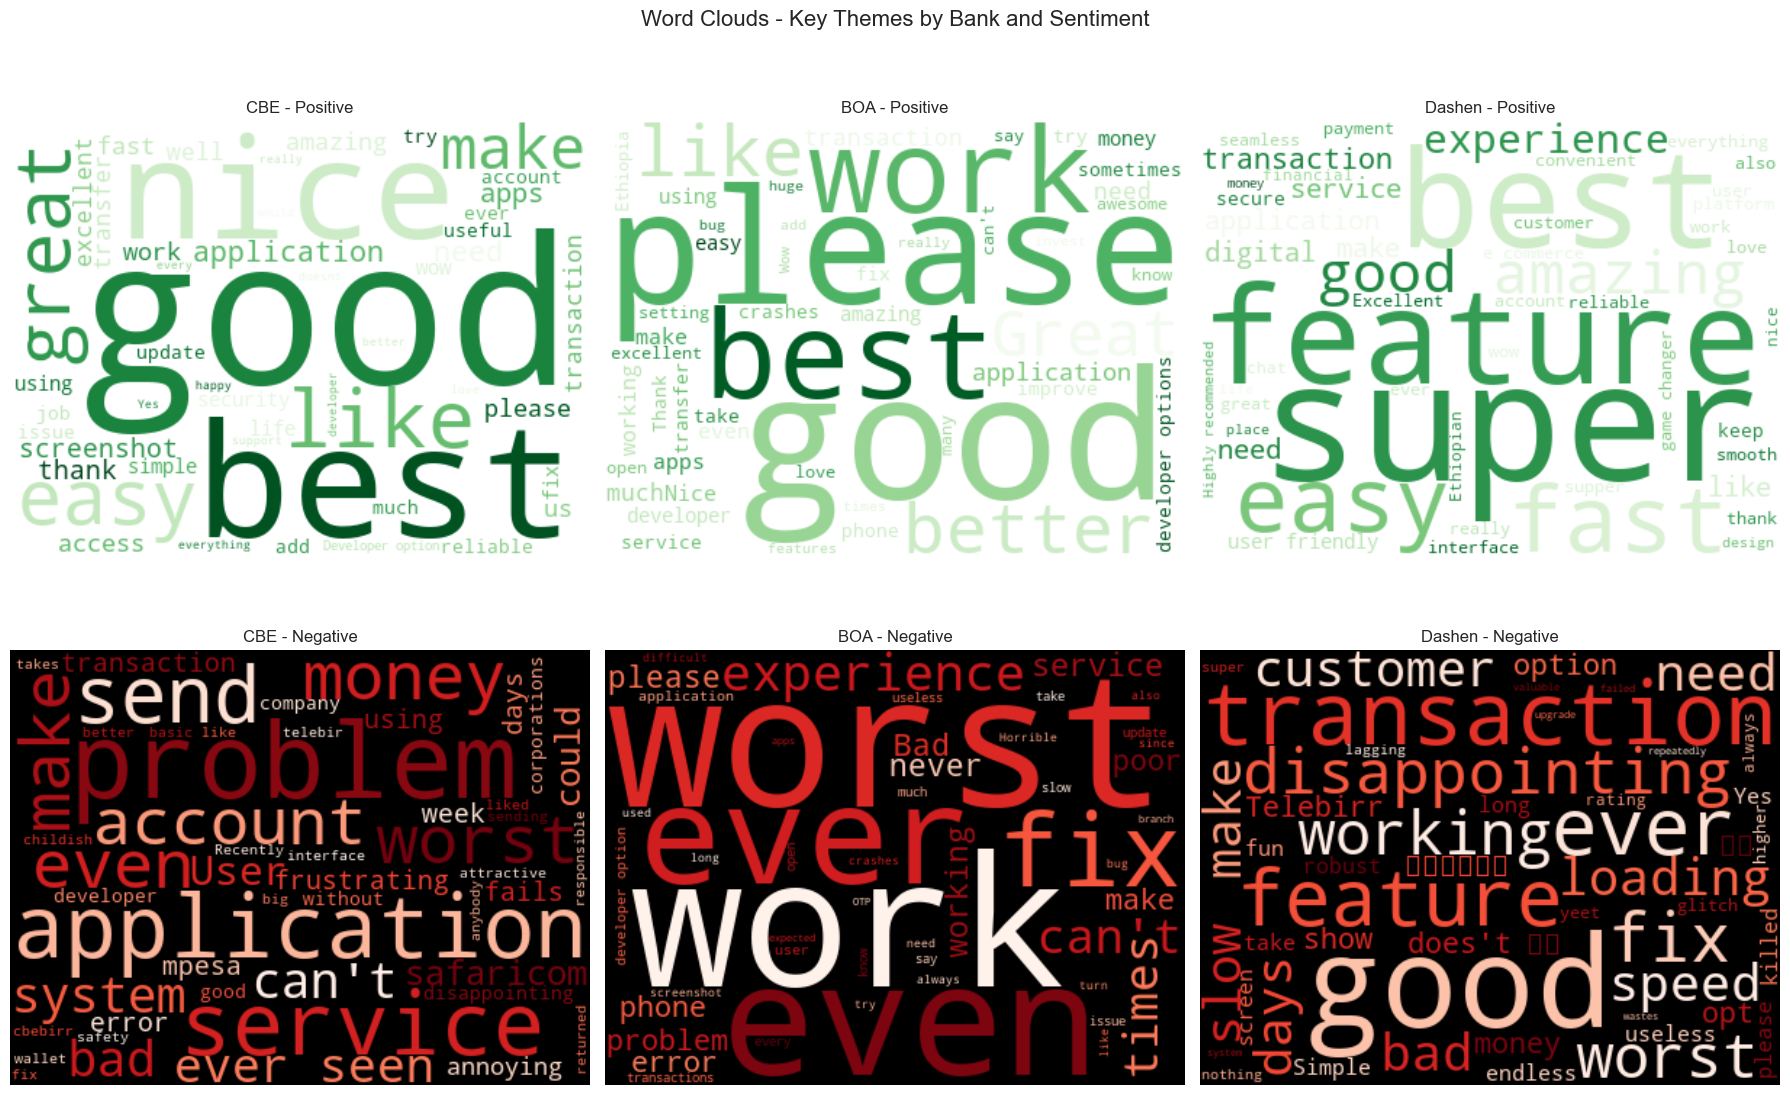

In [9]:

print("\n☁️ Generating Word Clouds...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Word Clouds - Key Themes by Bank and Sentiment', fontsize=16)

banks = df['bank'].unique()
sentiments = ['positive', 'negative']

for i, bank in enumerate(banks):
    for j, sentiment in enumerate(sentiments):
        ax = axes[j, i]
        
        # Get reviews for this bank and sentiment
        reviews = df[(df['bank'] == bank) & (df['sentiment_vader'] == sentiment)]['review']
        
        if len(reviews) > 0:
            text = ' '.join(reviews.fillna('').astype(str))
            
            # Create word cloud
            wordcloud = WordCloud(
                width=400, height=300,
                background_color='white' if sentiment == 'positive' else 'black',
                colormap='Greens' if sentiment == 'positive' else 'Reds',
                stopwords=stop_words,
                max_words=50
            ).generate(text)
            
            ax.imshow(wordcloud, interpolation='bilinear')
            ax.set_title(f'{bank} - {sentiment.capitalize()}')
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{bank} - {sentiment.capitalize()}')
        
        ax.axis('off')

plt.tight_layout()
plt.savefig('wordclouds_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

RATING VS SENTIMENT CORRELATION


📊 Analyzing Rating vs Sentiment Correlation...


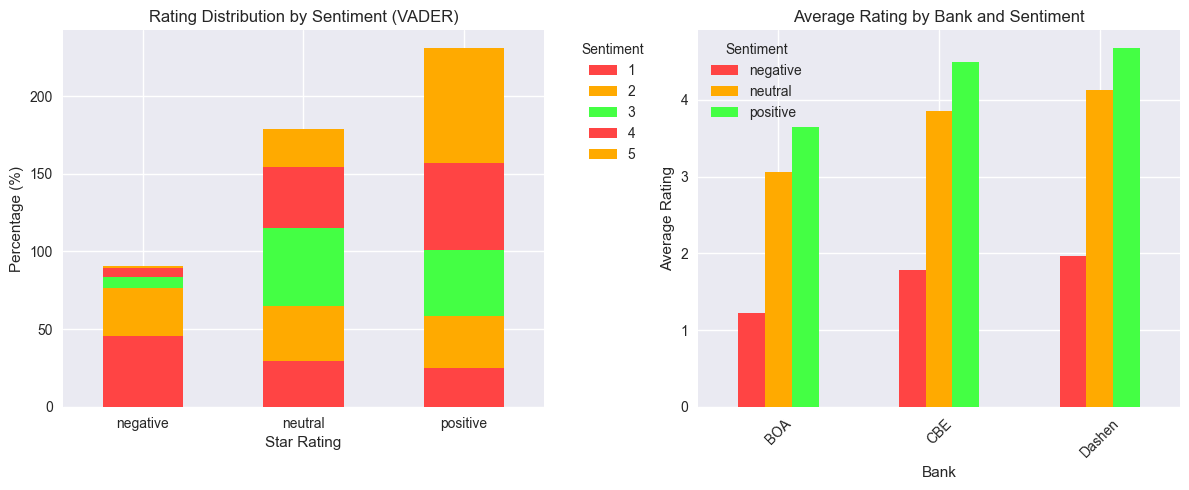

In [10]:

print("\n📊 Analyzing Rating vs Sentiment Correlation...")

# Create correlation matrix
correlation_data = pd.DataFrame({
    'Rating': df['rating'],
    'TextBlob_Sentiment': df['sentiment_textblob'].map({'positive': 1, 'neutral': 0, 'negative': -1}),
    'VADER_Sentiment': df['sentiment_vader'].map({'positive': 1, 'neutral': 0, 'negative': -1})
})

plt.figure(figsize=(12, 5))

# Rating distribution by sentiment
plt.subplot(1, 2, 1)
sentiment_rating = pd.crosstab(df['sentiment_vader'], df['rating'], normalize='columns') * 100
sentiment_rating.plot(kind='bar', stacked=True, ax=plt.gca(), 
                     color=['#ff4444', '#ffaa00', '#44ff44'])
plt.title('Rating Distribution by Sentiment (VADER)')
plt.xlabel('Star Rating')
plt.ylabel('Percentage (%)')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

# Average rating by bank and sentiment
plt.subplot(1, 2, 2)
avg_rating = df.groupby(['bank', 'sentiment_vader'])['rating'].mean().unstack()
avg_rating.plot(kind='bar', ax=plt.gca(), color=['#ff4444', '#ffaa00', '#44ff44'])
plt.title('Average Rating by Bank and Sentiment')
plt.xlabel('Bank')
plt.ylabel('Average Rating')
plt.legend(title='Sentiment')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('rating_sentiment_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

BUSINESS INSIGHTS SUMMARY

In [14]:
import os

# Ensure the data directory exists
os.makedirs('data', exist_ok=True)

print("\n BUSINESS INSIGHTS SUMMARY")
print("="*50)

# Overall satisfaction scores
overall_satisfaction = {}
for bank in df['bank'].unique():
    bank_data = df[df['bank'] == bank]
    positive_pct = (bank_data['sentiment_vader'] == 'positive').mean() * 100
    avg_rating = bank_data['rating'].mean()
    
    overall_satisfaction[bank] = {
        'positive_sentiment': positive_pct,
        'avg_rating': avg_rating,
        'total_reviews': len(bank_data)
    }

print("\n🏆 Bank Satisfaction Rankings:")
ranked_banks = sorted(overall_satisfaction.items(), 
                     key=lambda x: x[1]['positive_sentiment'], reverse=True)

for i, (bank, metrics) in enumerate(ranked_banks, 1):
    print(f"{i}. {bank}")
    print(f"   Positive Sentiment: {metrics['positive_sentiment']:.1f}%")
    print(f"   Average Rating: {metrics['avg_rating']:.1f}/5.0")
    print(f"   Total Reviews: {metrics['total_reviews']:,}")

# Key pain points and drivers
print("\n🎯 Key Findings:")

# Most common positive themes across all banks
all_positive_reviews = df[df['sentiment_vader'] == 'positive']['review']
if len(all_positive_reviews) > 0:
    positive_keywords = extract_keywords_tfidf(all_positive_reviews, max_features=10)
    print(f"\n✅ Top Satisfaction Drivers:")
    for i, (keyword, score) in enumerate(positive_keywords[:5], 1):
        print(f"   {i}. {keyword}")

# Most common negative themes across all banks
all_negative_reviews = df[df['sentiment_vader'] == 'negative']['review']
if len(all_negative_reviews) > 0:
    negative_keywords = extract_keywords_tfidf(all_negative_reviews, max_features=10)
    print(f"\n❌ Top Pain Points:")
    for i, (keyword, score) in enumerate(negative_keywords[:5], 1):
        print(f"   {i}. {keyword}")

# Save results to CSV for reporting
results_summary = pd.DataFrame([
    {
        'bank': bank,
        'total_reviews': metrics['total_reviews'],
        'avg_rating': round(metrics['avg_rating'], 2),
        'positive_sentiment_pct': round(metrics['positive_sentiment'], 1),
        'negative_sentiment_pct': round((df[df['bank'] == bank]['sentiment_vader'] == 'negative').mean() * 100, 1),
        'neutral_sentiment_pct': round((df[df['bank'] == bank]['sentiment_vader'] == 'neutral').mean() * 100, 1)
    }
    for bank, metrics in overall_satisfaction.items()
])

results_summary.to_csv('data/sentiment_analysis_summary.csv', index=False)
print(f"\n💾 Detailed results saved to 'data/sentiment_analysis_summary.csv'")



 BUSINESS INSIGHTS SUMMARY

🏆 Bank Satisfaction Rankings:
1. Dashen
   Positive Sentiment: 72.7%
   Average Rating: 4.4/5.0
   Total Reviews: 366
2. CBE
   Positive Sentiment: 61.1%
   Average Rating: 4.1/5.0
   Total Reviews: 321
3. BOA
   Positive Sentiment: 39.2%
   Average Rating: 2.8/5.0
   Total Reviews: 344

🎯 Key Findings:

✅ Top Satisfaction Drivers:
   1. good
   2. best
   3. super
   4. easy
   5. like

❌ Top Pain Points:
   1. worst
   2. ever
   3. even
   4. bad
   5. fix

💾 Detailed results saved to 'data/sentiment_analysis_summary.csv'
